Dataset Loaded Successfully
   Ticket_ID                   Customer_Message         Category Priority
0          1   Internet is not working properly  Technical Issue     High
1          2  Payment failed but money deducted    Billing Issue     High
2          3      Unable to login to my account      Login Issue   Medium
3          4     Application crashes frequently  Technical Issue     High
4          5  Need refund for wrong transaction    Billing Issue     High

Dataset Shape: (30, 4)


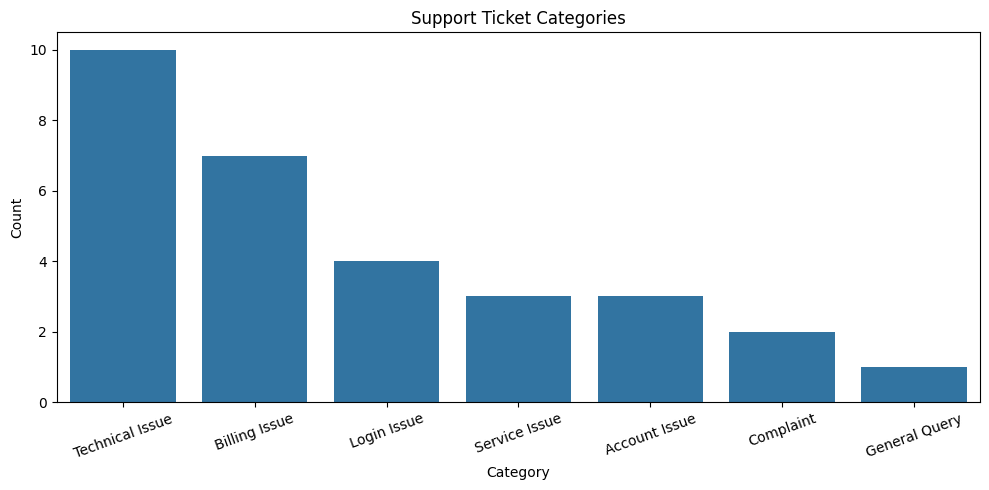


Predicted Categories:
['Billing Issue' 'Technical Issue' 'Technical Issue' 'Technical Issue'
 'Technical Issue' 'Technical Issue']

Actual Categories:
['Billing Issue', 'Technical Issue', 'Complaint', 'Account Issue', 'Account Issue', 'Technical Issue']

Accuracy Score: 0.5

Classification Report:

                 precision    recall  f1-score   support

  Account Issue       0.00      0.00      0.00         2
  Billing Issue       1.00      1.00      1.00         1
      Complaint       0.00      0.00      0.00         1
Technical Issue       0.40      1.00      0.57         2

       accuracy                           0.50         6
      macro avg       0.35      0.50      0.39         6
   weighted avg       0.30      0.50      0.36         6



c:\Users\SASHANK\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\SASHANK\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\SASHANK\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

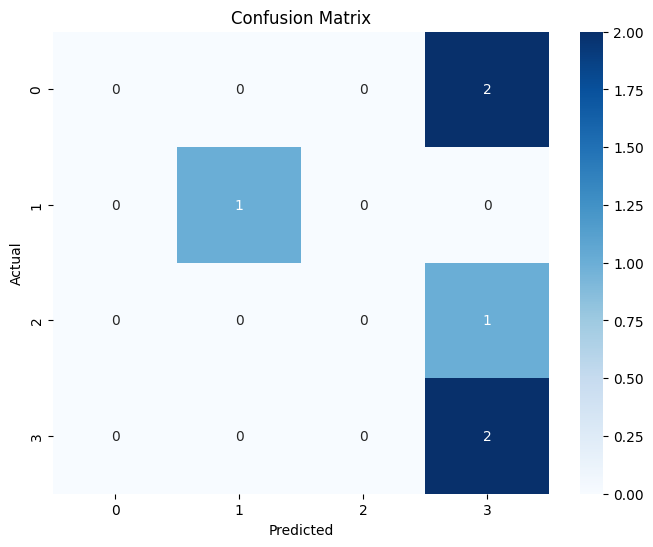


Sample Ticket Prediction:
Ticket: My payment failed and money was deducted
Predicted Category: Billing Issue


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# =========================
# CREATE DATASET
# =========================

csv_data = """Ticket_ID,Customer_Message,Category,Priority
1,Internet is not working properly,Technical Issue,High
2,Payment failed but money deducted,Billing Issue,High
3,Unable to login to my account,Login Issue,Medium
4,Application crashes frequently,Technical Issue,High
5,Need refund for wrong transaction,Billing Issue,High
6,Forgot my password,Login Issue,Medium
7,Slow network connection,Technical Issue,Medium
8,Product delivery delayed,Service Issue,Low
9,Account suspended without reason,Account Issue,High
10,Unable to update profile settings,Technical Issue,Medium
11,Incorrect bill amount charged,Billing Issue,High
12,Customer support not responding,Complaint,Medium
13,Mobile app not opening,Technical Issue,High
14,Need invoice copy,Billing Issue,Low
15,Password reset link not working,Login Issue,Medium
16,Service interrupted frequently,Technical Issue,High
17,Refund not processed,Billing Issue,High
18,Issue with account verification,Account Issue,Medium
19,Website loading very slowly,Technical Issue,Medium
20,Want to cancel subscription,Service Issue,Low
21,Payment gateway error,Billing Issue,High
22,Unable to receive OTP,Login Issue,Medium
23,System showing server error,Technical Issue,High
24,Complaint regarding poor service,Complaint,Medium
25,Account locked after login attempts,Account Issue,High
26,Need help with installation,Service Issue,Low
27,Data syncing problem detected,Technical Issue,Medium
28,Wrong amount debited twice,Billing Issue,High
29,Unable to access dashboard,Technical Issue,Medium
30,General inquiry about services,General Query,Low
"""

with open("support_tickets.csv", "w", encoding="utf-8") as file:
    file.write(csv_data)

# =========================
# LOAD DATASET
# =========================

data = pd.read_csv("support_tickets.csv")

print("Dataset Loaded Successfully")
print(data.head())
print("\nDataset Shape:", data.shape)

# =========================
# CATEGORY VISUALIZATION
# =========================

plt.figure(figsize=(10,5))

sns.countplot(x=data["Category"])

plt.title("Support Ticket Categories")
plt.xlabel("Category")
plt.ylabel("Count")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig("output_graphs/ticket_categories.png")

plt.show()

# =========================
# MACHINE LEARNING MODEL
# =========================

X = data["Customer_Message"]
y = data["Category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("classifier", MultinomialNB())
])

model.fit(X_train, y_train)

# =========================
# PREDICTIONS
# =========================

y_pred = model.predict(X_test)

print("\nPredicted Categories:")
print(y_pred)

print("\nActual Categories:")
print(list(y_test))

# =========================
# ACCURACY
# =========================

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy Score:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# =========================
# CONFUSION MATRIX
# =========================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("output_graphs/confusion_matrix.png")

plt.show()

# =========================
# SAMPLE PREDICTION
# =========================

sample_ticket = [
    "My payment failed and money was deducted"
]

prediction = model.predict(sample_ticket)

print("\nSample Ticket Prediction:")
print("Ticket:", sample_ticket[0])
print("Predicted Category:", prediction[0])